# GLASS Flows: Transition Sampling with Flow and Diffusion Models
### *A minimal implementation*

In this tutorial, I provide a minimal implementation of our work [GLASS Flows](https://arxiv.org/pdf/2509.25170). GLASS Flows is an ODE-based way of sampling stochastic Markov transitions in flow matching and diffusion models. You can think of GLASS Flows as *stochastic* flow matching or - in diffusion language - the *probability ODE* for SDEs. Here, I will focus on implementation. For a detailed description of method, I refer to our [GLASS Flows: Transition Sampling for Alignment of Flow and Diffusion Models](https://arxiv.org/pdf/2509.25170), in particular Algorithm 1 in the work.

In [126]:
import math
import time
import torch
from torch import nn, Tensor
import matplotlib.pyplot as plt
import numpy as np
from matplotlib import cm
from matplotlib.transforms import Bbox

Some utility functions.

In [2]:
def format_batch_variable(t, x_t):
    t = torch.tensor(t, device=x_t.device, dtype=x_t.dtype)
    if t.ndim == 0:
        t = t.unsqueeze(0)
    if len(t) < x_t.shape[0]:
        assert len(t) == 1
        t = torch.ones(size=(x_t.shape[0],),device=x_t.device, dtype=x_t.dtype) * t
    return t

def mult_first_dim(x, t):
    if t.ndim == 0:
        return t * x
    # Ensure t is a 1D tensor
    t = t.view(-1)
    # Check if the first dimension of x matches the size of t
    if x.size(0) != t.size(0):
        raise ValueError("The size of the vector t must match the first dimension of tensor x.")
    # Reshape t to enable broadcasting along the other dimensions of x
    t = t.view(-1, *([1] * (x.dim() - 1)))
    # Multiply x by t using broadcasting
    result = x * t
    return result
    
def grab(x):
    return x.detach().cpu().numpy()

# 1. Train Flow Matching Model

We first train a "standard" flow matching model to sample from a toy data distribution. The below is a generic implementation of flow matching and just included here for completeness.

As a dataset, I use a synthetic checkerboard dataset.

Text(0.5, 1.0, 'Dataset')

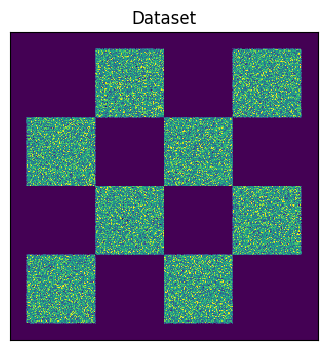

In [3]:
def inf_train_gen(batch_size: int = 200, device: str = "cpu"):
    x1 = torch.rand(batch_size, device=device) * 4 - 2
    x2_ = torch.rand(batch_size, device=device) - torch.randint(high=2, size=(batch_size, ), device=device) * 2
    x2 = x2_ + (torch.floor(x1) % 2)
    data = 1.0 * torch.cat([x1[:, None], x2[:, None]], dim=1) / 0.45
    
    return data.float()

def plot_emp_dist(samples, ax):
    H= ax.hist2d(samples[:,0], samples[:,1], 300, range=((-5,5), (-5,5)))
    cmax = np.percentile(H[0],99)
    cmin = 0.0
    norm = cm.colors.Normalize(vmax=cmax, vmin=cmin)
    _ = ax.hist2d(samples[:,0], samples[:,1], 300, range=((-5,5), (-5,5)), norm=norm)
    ax.set_aspect('equal')
    ax.set_xticks([])
    ax.set_yticks([])

VISUALIZATION_BATCH_SIZE = 300000
fig, ax = plt.subplots(figsize=(4,4))
samples = inf_train_gen(VISUALIZATION_BATCH_SIZE)
plot_emp_dist(samples, ax);
ax.set_title("Dataset")

To train a flow matching model on this dataset, we construct a simple multilayer perceptron (MLP) that represents the velocity field $u_t$.

In [4]:
class TimestepEmbedder(nn.Module):
    def __init__(self, dim, nfreq=256):
        super().__init__()
        self.mlp = nn.Sequential(nn.Linear(nfreq, dim), nn.SiLU(), nn.Linear(dim, dim))
        self.nfreq = nfreq

    @staticmethod
    def timestep_embedding(t, dim, max_period=10000):
        half_dim = dim // 2
        freqs = torch.exp(
            -math.log(max_period)
            * torch.arange(start=0, end=half_dim, dtype=torch.float32)
            / half_dim
        ).to(device=t.device)
        args = t[:, None].float() * freqs[None]
        embedding = torch.cat([torch.cos(args), torch.sin(args)], dim=-1)
        if dim % 2:
            embedding = torch.cat(
                [embedding, torch.zeros_like(embedding[:, :1])], dim=-1
            )
        return embedding

    def forward(self, t):
        t_freq = self.timestep_embedding(t, self.nfreq)
        t_emb = self.mlp(t_freq)
        return t_emb

# activation and model
class Swish(nn.Module):
    def __init__(self):
        super().__init__()

    def forward(self, x): 
        return torch.sigmoid(x)*x

class Flow(nn.Module):
    def __init__(self,
                 input_dim=2,
                 time_emb_dim=16,
                 hidden_dim=128,
                 act=Swish(),
                 output_dim=2,
                 num_classes=None,
                 clip_val: float = 1e-8,
                 cfg_scale: float = 1.0
                 ):
        super().__init__()
        self.clip_val = clip_val
        self.input_dim = input_dim
        self.time_emb_dim = time_emb_dim
        self.hidden_dim = hidden_dim
        self.output_dim = output_dim
        self.act = act
        self.num_classes = num_classes
        self.cfg_scale = cfg_scale
        if num_classes is not None:
            raise NotImplementedError()
        self.t_emb = TimestepEmbedder(dim=time_emb_dim)

        self.main = nn.Sequential(
            nn.Linear(input_dim+time_emb_dim, hidden_dim),
            act,
            nn.Linear(hidden_dim, hidden_dim),
            act,
            nn.Linear(hidden_dim, hidden_dim),
            act,
            nn.Linear(hidden_dim, hidden_dim),
            act,
            nn.Linear(hidden_dim, output_dim),
            )

    def forward(self, x_t, t, extra={}):
        if "label" in extra:
            raise NotImplementedError()
        t_emb = self.t_emb(t.squeeze())
        h = torch.cat([x_t, t_emb], dim=1) # concat
        output = self.main(h) # forward
        return output
    
    def euler_step(self, x_t, t_start, t_next, extra={}):
        dt = t_next - t_start
        velocity = self.forward(x_t, t_start, extra=extra)
        x_next = x_t + velocity * dt[:,None]
        return x_next

In [5]:
N_EPOCHS = 50000
RETRAIN_FLOW = False # Whether to re-train or load the model

Let's train:

In [6]:
device = torch.device('cuda')
model = Flow().to(device)
if RETRAIN_FLOW:
    optimizer = torch.optim.Adam(model.parameters(), 0.001)
    loss_fn = nn.MSELoss()
    batch_size = 4096
    for epoch in range(N_EPOCHS):
        if epoch % 100 == 0:
            print(f"epoch: {epoch}")
        x_1 = inf_train_gen(batch_size).to(device)
        x_0 = torch.randn_like(x_1).to(device)
        t = torch.rand(len(x_1), 1).to(device)
        x_t = (1 - t) * x_0 + t * x_1
        dx_t = x_1 - x_0
        optimizer.zero_grad()
        loss_fn(model(t=t, x_t=x_t), dx_t).backward()
        optimizer.step()
    torch.save(model.state_dict(),"./fm_checkerboard.ckpt")
else:
    model.load_state_dict(torch.load("./fm_checkerboard.ckpt"))

Let's sample by simulating the ODE:

/tmp/ipykernel_545300/899490743.py:2: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  t = torch.tensor(t, device=x_t.device, dtype=x_t.dtype)


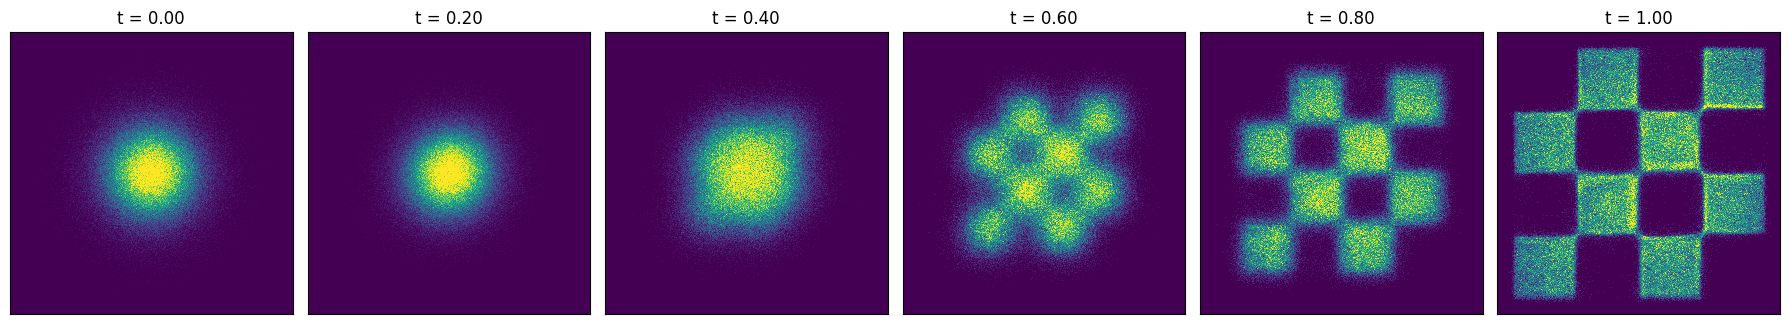

In [7]:
x = torch.randn(VISUALIZATION_BATCH_SIZE, 2).to(device)
n_steps = 20
n_plots = 6  # number of visualized timesteps
fig, axes = plt.subplots(1, n_plots, figsize=(18, 4), sharex=True, sharey=True)

time_steps = torch.linspace(0, 1.0, n_steps + 1).to(device)
# choose evenly spaced time indices to visualize
plot_indices = torch.linspace(0, n_steps, n_plots, dtype=torch.long)

plot_dict_flow = {}
plot_dict_flow[f'{0.0:.2f}'] = x.cpu()

with torch.no_grad():
    for i in range(n_steps):
        t_start = format_batch_variable(time_steps[i], x)
        t_next = format_batch_variable(time_steps[i + 1], x)
        x = model.euler_step(x_t=x, t_start=t_start, t_next=t_next).detach()

        # visualize if this step corresponds to one of our chosen times
        if (i + 1) in plot_indices:
            idx = (plot_indices == (i + 1)).nonzero(as_tuple=True)[0].item()
            plot_dict_flow[f'{time_steps[i + 1]:.2f}'] = x.cpu()

for idx, (time, x) in enumerate(plot_dict_flow.items()):
    plot_emp_dist(x.cpu(), axes[idx])
    axes[idx].set_title(f't = {time}')
    axes[idx].set_xlim(-5.0, 5.0)
    axes[idx].set_ylim(-5.0, 5.0)
    axes[idx].set_aspect('equal')

plt.tight_layout()
plt.show()


## 2. Define GLASS Flows reparameterization

In [8]:
torch.set_grad_enabled(False)

torch.autograd.grad_mode.set_grad_enabled(mode=False)

In [54]:
class GlassFlow(nn.Module):
    """A module that takes in a flow matching model and converts it into a posterior flow matching model"""
    def __init__(self,
                 fm_model: nn.Module,
                 clip_val: float = 1e-8,
                 t_min: float = 0.001,
                 t_max: float = 0.999,
                 eta_t_clip: float = 200.0,
                 ):
        """
        fm_model: a flow matching model that accepts an x_t and t arguments and returns a velocity
        """
        super().__init__()
        self.fm_model = fm_model
        self.clip_val = clip_val
        self.t_min = t_min
        self.t_max = t_max
        self.eta_t_clip = eta_t_clip
        
    def denoiser(self, x_t, t, **kwargs):
        t = format_batch_variable(t, x_t)
        return x_t + mult_first_dim(self.fm_model(x_t=x_t,t=t, **kwargs), 1-t)

    def alpha_t(self, t):
        return t

    def dot_alpha_t(self, t):
        return torch.ones_like(t)
        
    def sigma_t(self, t):
        return 1-t

    def dot_sigma_t(self, t):
        return -torch.ones_like(t)

    def g_t(self, t):
        return (self.sigma_t_start(t)/torch.clip(self.alpha_t_start(t),min=self.clip_val))**2
    
    def g_t_inv(self, inp_):
        return 1/(1+torch.sqrt(inp_))

    def bar_alpha_s(self, s: Tensor, bar_alpha_final: float):
        return bar_alpha_final*s

    def dot_bar_alpha_s(self, s: Tensor, bar_alpha_final: float):
         return bar_alpha_final*torch.ones_like(s)
        
    def bar_sigma_s(self, s: Tensor, sigma_cond_final: float):
        return s * sigma_cond_final + (1-s)

    def dot_bar_sigma_s(self, s: Tensor, sigma_cond_final: float):
        return torch.ones_like(s) * (sigma_cond_final - 1.0)
    
    def get_num_stable_inverse(self, matrix: Tensor):
        return torch.linalg.inv(matrix + 0.0001 * self.clip_val * torch.eye(matrix.shape[0], device=matrix.device, dtype=matrix.dtype))

    
    def get_generalized_denoiser(self, mu_s: Tensor, Cov_s: Tensor, X_t: Tensor, bar_X_s: Tensor, dtype: torch.dtype, precdtype: torch.dtype, **kwargs):
        inv_Cov_s = self.get_num_stable_inverse(Cov_s)
        bproduct = mu_s @ inv_Cov_s @ mu_s
        t_star = self.g_t_inv(1/torch.clip(bproduct,min=self.clip_val))

        # Compute sufficient statistic:
        weights = self.alpha_t(t_star) * (mu_s @ inv_Cov_s)/torch.clip(bproduct,min=self.clip_val)
        scaled_suff_stat = weights[0] * X_t + weights[1] * bar_X_s

        # Get denoiser
        denoiser = self.denoiser(x_t=scaled_suff_stat.to(dtype), 
                                 t=t_star.to(dtype), 
                                 **kwargs).to(dtype=precdtype)
        return denoiser

        
    def simulate_glass_flow(self,
                          s_vec: Tensor,
                          bar_X_s_init: Tensor,
                          X_t: Tensor, 
                          t_start: Tensor,
                          t_end: Tensor,
                          corr_rho: Tensor,
                          dtype: torch.dtype,
                          device: torch.device,
                          schedule: str = "s_linear",
                          return_traj: bool = False,
                          precdtype: torch.dtype = torch.float64,
                          **kwargs):

        # Get mean and variance scales:
        alpha_t_start = self.alpha_t(t_start).to(precdtype)
        alpha_t_end = self.alpha_t(t_end).to(precdtype)
        sigma_t_start = self.sigma_t(t_start).to(precdtype)
        sigma_t_end = self.sigma_t(t_end).to(precdtype)

        # Conditional distribution:
        bar_gamma = corr_rho * sigma_t_end/torch.clip(sigma_t_start, min=self.clip_val)
        bar_alpha_final = alpha_t_end - bar_gamma * alpha_t_start
        bar_sigma_final = torch.sqrt(torch.clip((sigma_t_end**2) * (1-corr_rho**2),min=0.0))

        # Get schedulers for inner probability path:
        bar_alpha_s = self.bar_alpha_s(s_vec, bar_alpha_final)
        dot_bar_alpha_s = self.dot_bar_alpha_s(s_vec, bar_alpha_final)
        bar_sigma_s = self.bar_sigma_s(s_vec, bar_sigma_final)
        dot_bar_sigma_s = self.dot_bar_sigma_s(s_vec, bar_sigma_final)

        # Get weights:
        w_1 = dot_bar_sigma_s/torch.clip(bar_sigma_s,min=self.clip_val)
        w_2 = dot_bar_alpha_s - w_1 * bar_alpha_s
        w_3 = - w_1 * bar_gamma

        # Convert to higher precision:
        X_t = X_t.to(dtype=precdtype)

        # Initialize:
        bar_X_s = bar_X_s_init

        if return_traj:
            traj_list = [bar_X_s.cpu().detach().float()]

        n_steps = len(s_vec) - 1
        for i in range(n_steps):


            # Compute t_star:
            mu_s = torch.tensor([alpha_t_start, bar_alpha_s[i]+bar_gamma*alpha_t_start], dtype=precdtype, device=device)
            Cov_s = torch.tensor([[sigma_t_start**2, bar_gamma*(sigma_t_start**2)],
                                   [bar_gamma*(sigma_t_start**2), bar_sigma_s[i]**2 + (bar_gamma**2)*(sigma_t_start**2)]], 
                                    dtype=precdtype, device=device)
            
            denoiser = self.get_generalized_denoiser(
                                                    X_t=X_t, 
                                                    bar_X_s=bar_X_s,
                                                    mu_s=mu_s, 
                                                    Cov_s=Cov_s, 
                                                    dtype=dtype, 
                                                    precdtype=precdtype, 
                                                    **kwargs)

            # Get velocity:
            velocity = w_1[i] * bar_X_s + w_2[i] * denoiser + w_3[i] * X_t

            # Take Euler step:
            s_curr = s_vec[i]
            s_next = s_vec[i+1]
            bar_X_s = bar_X_s + (s_next - s_curr) * velocity

            if return_traj:
                traj_list.append(bar_X_s.cpu().detach())
        
        if return_traj:
            return traj_list
        else:
            return bar_X_s

    def get_bar_gamma(self, t_start, t_end, corr_rho):
        bar_gamma = corr_rho * self.sigma_t(t_end)/torch.clip(self.sigma_t(t_start), min=self.clip_val)
        return bar_gamma
    
        
    def sample_glass_transition(self, X_t: Tensor, corr_rho: float, t_start: Tensor, t_end: Tensor, precdtype: torch.dtype = torch.float64, n_steps: int = 10, **kwargs):
        s_vec = torch.linspace(self.t_min, self.t_max, n_steps+1, dtype=precdtype, device=device)
        bar_gamma = self.get_bar_gamma(t_start, t_end, corr_rho).to(precdtype)
        bar_X_s_init = bar_gamma * X_t + torch.randn_like(X_t)
        
        return self.simulate_glass_flow(s_vec=s_vec, 
                                        bar_X_s_init=bar_X_s_init, 
                                        X_t=X_t, 
                                        precdtype=precdtype, 
                                        corr_rho=corr_rho, 
                                        t_start=t_start,
                                        t_end=t_end,
                                        **kwargs)
        
    
    def velocity_to_score(self, x_t: Tensor, t: Tensor, velocity: Tensor):
        """Function that convert a FM velocity to a score function"""

        # Compute scheduler functions:
        alpha_t = self.alpha_t(t)
        sigma_t = self.sigma_t(t)
        dot_alpha_t = self.dot_alpha_t(t)
        dot_sigma_t = self.dot_sigma_t(t)
        
        # Compute score
        denominator = (sigma_t**2) * dot_alpha_t - alpha_t * dot_sigma_t * sigma_t
        numerator = mult_first_dim(velocity, alpha_t) - mult_first_dim(x_t, dot_alpha_t)
        score_val = mult_first_dim(numerator, 1/torch.clip(denominator, min=self.clip_val))

        return score_val
    
    def memoryless_euler_step_given_v_t(self, x_t: Tensor, t_start: Tensor, t_end: Tensor, v_t: Tensor, last_step_drop: bool = False, **kwargs) -> Tensor:
        """Euler step for SDE"""
        t_start = format_batch_variable(t=t_start, x_t=x_t)
        t_end = format_batch_variable(t=t_end, x_t=x_t)
        noise = torch.randn_like(x_t)
        eta_t = (self.sigma_t(t_start)**2)*self.dot_alpha_t(t_start)/torch.clip(self.alpha_t(t_start),min=self.clip_val)\
                        - self.sigma_t(t_start) * self.dot_sigma_t(t_start)
        eta_t = torch.clip(eta_t, min=0.0, max=self.eta_t_clip)
        if last_step_drop:
            if self.last_sde_step == "mean":
                eta_t = eta_t
            elif self.last_sde_step == "euler":
                eta_t = torch.zeros_like(eta_t)
            else:
                raise NotImplementedError(f"Last SDE step {self.last_sde_step} not implemented. Use 'mean' or 'euler'.")
        diff_coeff = torch.sqrt(2*eta_t) if not last_step_drop else torch.zeros_like(eta_t)
        diff_delta = mult_first_dim(noise, torch.sqrt(t_end - t_start) * diff_coeff)
        score = self.velocity_to_score(x_t=x_t, t=t_start, velocity=v_t)
        scaled_score = mult_first_dim(score, eta_t)
        total_velocity = v_t + scaled_score
        flow_delta = mult_first_dim(total_velocity, t_end - t_start)
        return x_t + flow_delta + diff_delta
        
    def memoryless_euler_step(self, x_t: Tensor, t_start: Tensor, t_end: Tensor, last_step_drop: bool = False, **kwargs) -> Tensor:
        """Euler step for SDE"""
        marginal_velocity = self.fm_model(x_t=x_t, t=t_start)
        return self.memoryless_euler_step_given_v_t(x_t=x_t,
                                                     t_start=t_start, 
                                                     t_end=t_end, 
                                                     v_t=marginal_velocity, 
                                                     last_step_drop=last_step_drop, 
                                                     **kwargs)
    
    def sample_transition_ddpm_with_sde(self, x_t: Tensor, t_start: Tensor, t_next: Tensor, n_steps: int = 20, return_traj: bool = False, last_step_drop: bool = False, **kwargs):
        t_start = format_batch_variable(t_start, x_t)
        unit_time_steps = torch.linspace(self.t_min, self.t_max, n_steps+1).to(x_t.device)
        if return_traj:
            traj_list = [x_t.cpu().detach()]
        x = x_t
        for i in range(n_steps):
            t_low = t_start + (t_next-t_start) * unit_time_steps[i]
            t_high = t_start + (t_next-t_start) * unit_time_steps[i+1]
            last_step_drop_it = (i >= n_steps - 1) if last_step_drop else False
            x = self.memoryless_euler_step(x_t=x, t_start=t_low, t_end=t_high, last_step_drop=last_step_drop_it, **kwargs)
            if return_traj:
                traj_list.append(x.cpu().detach())
        if return_traj:
            return traj_list, unit_time_steps
        else:
            return x

In [55]:
glass_flow = GlassFlow(fm_model=model)

/tmp/ipykernel_545300/899490743.py:2: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  t = torch.tensor(t, device=x_t.device, dtype=x_t.dtype)


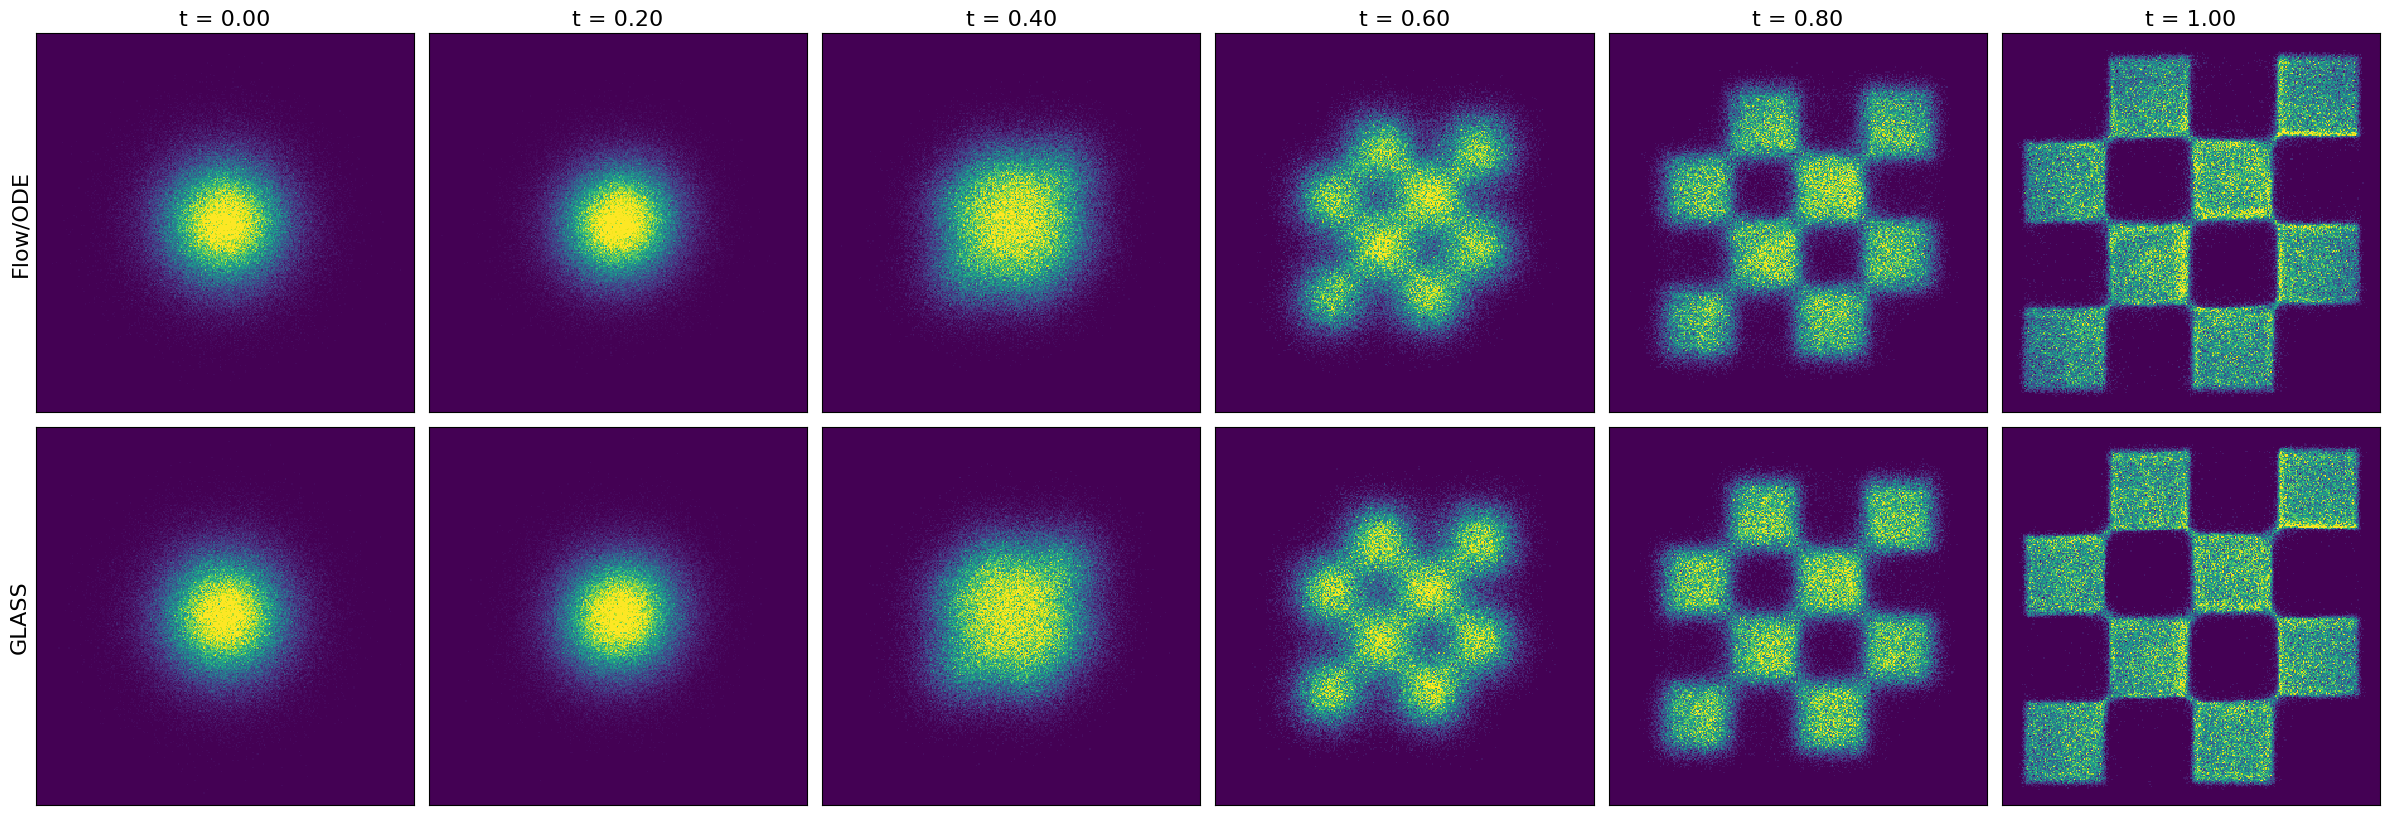

In [56]:
n_transitions = 6
t_backbone = torch.linspace(0,1,n_transitions)
batch_size = 300000
fontsize=16
plot_dict_glass = {}
X = torch.randn(size=(batch_size,2), device=device)
plot_dict_glass[f'{0.0:.2f}'] = X.cpu()
for idx in range(n_transitions-1):
    t_start = t_backbone[idx]
    t_end = t_backbone[idx+1]
    X = glass_flow.sample_glass_transition(
          X_t=X, 
          n_steps=10,
          t_start=t_start,
          t_end=t_end,
          corr_rho=0.4,
          dtype=torch.float32,
          device=device,
          precdtype=torch.float32)
    plot_dict_glass[f'{t_end:.2f}'] = X.cpu()

    
plt.show()

fig, axes = plt.subplots(2, n_transitions, figsize=(4*n_transitions, 2.10*4), sharex=True, sharey=True)
# plot_emp_dist(X.cpu(),axes[0])
# axes[0,].set_title(f't = {t_end:.2f}')

for idx, (time, x) in enumerate(plot_dict_flow.items()):
    plot_emp_dist(x.cpu(), axes[0, idx])
    axes[0, idx].set_title(f't = {time}',fontsize=fontsize)
    axes[0, idx].set_xlim(-5.0, 5.0)
    axes[0, idx].set_ylim(-5.0, 5.0)
    axes[0, idx].set_aspect('equal')

axes[0, 0].set_ylabel("Flow/ODE", fontsize=fontsize)

for idx, (time, x) in enumerate(plot_dict_glass.items()):
    plot_emp_dist(x.cpu(), axes[1, idx])
    axes[1, idx].set_xlim(-5.0, 5.0)
    axes[1, idx].set_ylim(-5.0, 5.0)
    axes[1, idx].set_aspect('equal')

axes[1, 0].set_ylabel("GLASS", fontsize=fontsize)

plt.tight_layout()
plt.show()

Let's visualize the trajectories of a GLASS Transition from $t=0.3$ to $t=1$.

In [100]:
batch_size = 4
traj = [X]
t_start = torch.tensor(0.2, device=device)
t_end = torch.tensor(1.0, device=device)
X_start = torch.tensor([0.0, 0.0], device=device)
X = torch.stack([X_start]*batch_size)
traj_dict = {}
n_steps = 500

# Sample transition with SDE:
traj,_ = glass_flow.sample_transition_ddpm_with_sde(
      x_t=X,
      n_steps=n_steps,
      t_start=t_start,
      t_next=t_end,
      return_traj=True,
      dtype=torch.float32,
      device=device)

trajs = torch.stack(traj)
X_start = trajs[0,0,:]
trajs = trajs[1:,:,:]
traj_dict["SDE"] = (trajs, X_start)



# Sample transition with ODE:
ddpm_corr = glass_flow.alpha_t(t_start)*glass_flow.sigma_t(t_end)\
            /torch.clip(glass_flow.alpha_t(t_end) * glass_flow.sigma_t(t_start),min=glass_flow.clip_val)

s_vec = torch.linspace(glass_flow.t_max, glass_flow.t_min, n_steps+1, dtype=torch.float64, device=device)
bar_X_s_init = glass_flow.simulate_glass_flow(s_vec=s_vec, 
                                bar_X_s_init=trajs[-1].to(device), 
                                X_t=X, 
                                precdtype=torch.float64, 
                                corr_rho=ddpm_corr, 
                                t_start=t_start,
                                t_end=t_end,
                                return_traj=False,
                                device=device,
                               dtype=torch.float32)

s_vec = torch.linspace(glass_flow.t_min, glass_flow.t_max, n_steps+1, dtype=torch.float64, device=device)
traj = glass_flow.simulate_glass_flow(s_vec=s_vec, 
                                bar_X_s_init=bar_X_s_init, 
                                X_t=X, 
                                precdtype=torch.float64, 
                                corr_rho=ddpm_corr, 
                                t_start=t_start,
                                t_end=t_end,
                                return_traj=True,
                                device=device,
                               dtype=torch.float32)

trajs = torch.stack(traj)
traj_dict["GLASS"] = (trajs, None)

/tmp/ipykernel_545300/899490743.py:2: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  t = torch.tensor(t, device=x_t.device, dtype=x_t.dtype)


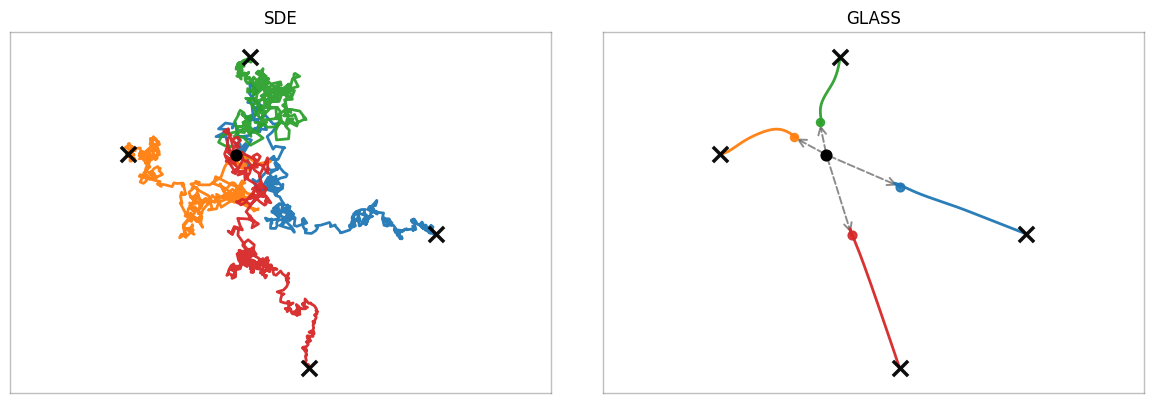

In [101]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.patches import FancyArrowPatch
import torch

def adjust_bounds_fill_6by4(ax, points, pad=0.08):
    points = np.asarray(points)
    x_min, x_max = points[:, 0].min(), points[:, 0].max()
    y_min, y_max = points[:, 1].min(), points[:, 1].max()

    current_w = x_max - x_min
    current_h = y_max - y_min
    target_ratio = 6/4

    if current_w <= 0: current_w = 1.0
    if current_h <= 0: current_h = 1.0

    if current_w / current_h < target_ratio:
        cx = (x_max + x_min) / 2
        new_w = current_h * target_ratio
        x_min, x_max = cx - new_w/2, cx + new_w/2
    else:
        cy = (y_max + y_min) / 2
        new_h = current_w / target_ratio
        y_min, y_max = cy - new_h/2, cy + new_h/2

    pad_x = (x_max - x_min) * pad
    pad_y = (y_max - y_min) * pad
    ax.set_xlim(x_min - pad_x, x_max + pad_x)
    ax.set_ylim(y_min - pad_y, y_max + pad_y)
    ax.set_aspect('equal')

def plot_trajs_panel(ax, trajs, X_start, colors, show_initialization=True):
    """
    trajs: torch.Tensor (T, N, 2)
    X_start: torch.Tensor (2,)
    colors: list of RGBA tuples, length >= N
    show_initialization:
        - True: draw dashed gray arrows & colored initial dots
        - False: only show trajectories starting visually at X_start
    """
    gray = '#666666'

    # convert to numpy
    T, N, D = trajs.shape
    assert D == 2
    trajs_np = trajs.detach().cpu().numpy()
    Xs_np = X_start.detach().cpu().numpy()

    # collect points for bounds
    all_pts = [trajs_np.reshape(-1, 2), Xs_np[None, :]]

    # starting black dot and label
    ax.scatter(Xs_np[0], Xs_np[1], c='black', s=60, zorder=5)
    # ax.annotate(r"$x_t$", (Xs_np[0], Xs_np[1]),
    #             textcoords="offset points", xytext=(6, 6),
    #             fontsize=12, color='black')

    if show_initialization:
        initial = trajs_np[0]  # (N, 2)
        radii = np.linalg.norm(initial - Xs_np[None, :], axis=1)
        rmax = max(radii.max(), 1e-6)

        # dashed gray arrows from x_t to initial
        for i in range(N):
            arrow = FancyArrowPatch(
                (Xs_np[0], Xs_np[1]),
                (initial[i, 0], initial[i, 1]),
                connectionstyle="arc3,rad=0",
                arrowstyle='->',
                mutation_scale=14,
                linestyle='--',
                color=gray,
                linewidth=1.4,
                alpha=0.75,
                zorder=2
            )
            ax.add_patch(arrow)

        # colored initial dots
        init_sizes = 30 + 10 * (radii / rmax)
        for i in range(N):
            ax.scatter(initial[i, 0], initial[i, 1],
                       c=[colors[i]], s=init_sizes[i], zorder=4, alpha=0.9)

    # trajectories as simple lines (no arrowheads)
    for i in range(N):
        path = trajs_np[:, i, :]
        ax.plot(path[:, 0], path[:, 1],
                linewidth=2.0, alpha=0.95,
                color=colors[i], zorder=3)

    # end points as black crosses
    ends = trajs_np[-1]
    ax.scatter(ends[:, 0], ends[:, 1],
               c='black', s=120, marker='x',
               linewidths=2.5, zorder=4, alpha=0.95)

    # style
    all_pts = np.vstack(all_pts)
    adjust_bounds_fill_6by4(ax, all_pts, pad=0.08)
    ax.grid(True, alpha=0.15, linewidth=0.5)
    ax.set_xticks([]); ax.set_yticks([])
    for spine in ax.spines.values():
        spine.set_linewidth(1.0); spine.set_color('gray'); spine.set_alpha(0.5)

def plot_traj_dict(traj_dict):
    """
    traj_dict: dict[str, tuple[torch.Tensor(T,N,2), torch.Tensor(2,)]]
    Creates one subplot per key. First subplot: no init arrows.
    Subsequent subplots: dashed gray arrows + colored init dots.
    """
    names = list(traj_dict.keys())
    assert len(names) >= 1

    # find maximum number of trajectories
    N_max = max(traj_dict[name][0].shape[1] for name in names)

    cmap = plt.get_cmap('tab20' if N_max > 10 else 'tab10')
    base_colors = [cmap(i % cmap.N) for i in range(N_max)]

    fig, axes = plt.subplots(1, len(names), figsize=(6*len(names), 4), squeeze=False)
    axes = axes[0]

    for idx, name in enumerate(names):
        trajs, _ = traj_dict[name]
        colors = base_colors[:trajs.shape[1]]
        show_init = (idx != 0)
        plot_trajs_panel(axes[idx], trajs, X_start, colors, show_initialization=show_init)
        axes[idx].set_title(name, fontsize=12)

    plt.tight_layout()
    return fig

#Example usage
fig = plot_traj_dict(traj_dict)
plt.show()


In [137]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.patches import FancyArrowPatch
from matplotlib.animation import FuncAnimation, PillowWriter
import torch

def adjust_bounds_square(ax, points, pad=0.08):
    points = np.asarray(points)
    x_min, x_max = points[:, 0].min(), points[:, 0].max()
    y_min, y_max = points[:, 1].min(), points[:, 1].max()
    cx, cy = (x_max + x_min)/2, (y_max + y_min)/2
    half = max(x_max - x_min, y_max - y_min) / 2
    half *= 1 + pad
    ax.set_xlim(cx - half, cx + half)
    ax.set_ylim(cy - half, cy + half)
    ax.set_aspect('equal')

def animate_traj_dict(
    traj_dict,
    out_path="trajectories.gif",
    fps=30,
    start_pause_s=0.5,
    draw_duration_s=3.0,
    end_pause_s=1.5,
    dpi_save=150,   # moderate resolution to keep file size reasonable
):
    names = list(traj_dict.keys())
    assert len(names) >= 1

    N_max = max(traj_dict[name][0].shape[1] for name in names)
    cmap = plt.get_cmap('tab20' if N_max > 10 else 'tab10')
    base_colors = [cmap(i % cmap.N) for i in range(N_max)]

    panels = []
    for name in names:
        trajs, _ = traj_dict[name]  # keep your original pattern
        trajs_np = trajs.detach().cpu().numpy()
        Xs_np = X_start.detach().cpu().numpy()  # global or outer-scope X_start as you intended
        pts = np.vstack([trajs_np.reshape(-1, 2), Xs_np[None, :]])
        panels.append({
            "name": name,
            "trajs_np": trajs_np,
            "X_start": Xs_np,
            "T": trajs_np.shape[0],
            "N": trajs_np.shape[1],
            "colors": base_colors[:trajs_np.shape[1]],
            "bounds_pts": pts
        })

    # Square panels, tighter spacing, with more bottom margin for a full-width legend
    # right after creating the figure/axes
    fig, axes = plt.subplots(1, len(names), figsize=(4*len(names), 4), squeeze=False)
    axes = axes[0]
    
    # minimal outer margins + tight spacing between subplots
    plt.subplots_adjust(left=0.02, right=0.98, top=0.98, bottom=0.14, wspace=0.06, hspace=0.06)
    
    # compute the union bbox of all subplots (in figure coords)
    grid_bbox = Bbox.union([ax.get_position(fig) for ax in axes])
    x0, y0, x1, y1 = grid_bbox.x0, grid_bbox.y0, grid_bbox.x1, grid_bbox.y1

    animated_lines, animated_end_scats, static_artists = [], [], []

    for idx, (ax, panel) in enumerate(zip(axes, panels)):
        trajs_np = panel["trajs_np"]
        Xs_np = panel["X_start"]
        N_i, T_i = panel["N"], panel["T"]
        colors = panel["colors"]

        adjust_bounds_square(ax, panel["bounds_pts"], pad=0.08)
        ax.grid(True, alpha=0.15, linewidth=0.5)
        ax.set_xticks([]); ax.set_yticks([])
        for spine in ax.spines.values():
            spine.set_linewidth(1.0); spine.set_color('gray'); spine.set_alpha(0.5)
        # No titles

        # start point (no math annotation)
        s_xt = ax.scatter(Xs_np[0], Xs_np[1], c='black', s=60, zorder=5)
        panel_statics = [s_xt]

        # dashed gray arrows + colored initial dots for subplots after the first
        if idx != 0:
            gray = '#666666'
            initial = trajs_np[0]
            radii = np.linalg.norm(initial - Xs_np[None, :], axis=1)
            rmax = max(radii.max(), 1e-6)
            for i in range(N_i):
                arrow = FancyArrowPatch(
                    (Xs_np[0], Xs_np[1]),
                    (initial[i, 0], initial[i, 1]),
                    connectionstyle="arc3,rad=0",
                    arrowstyle='->',
                    mutation_scale=14,
                    linestyle='--',
                    color=gray,
                    linewidth=1.4,
                    alpha=0.75,
                    zorder=2
                )
                ax.add_patch(arrow)
                panel_statics.append(arrow)
            init_sizes = 60 + 40 * (radii / rmax)
            for i in range(N_i):
                s = ax.scatter(initial[i, 0], initial[i, 1],
                               c=[colors[i]], s=init_sizes[i],
                               zorder=4, alpha=0.9)
                panel_statics.append(s)

        static_artists.append(panel_statics)

        # animated trajectory lines
        panel_lines = []
        for i in range(N_i):
            ln, = ax.plot([], [], linewidth=2.0, alpha=0.95,
                          color=colors[i], zorder=3)
            panel_lines.append(ln)
        animated_lines.append(panel_lines)

        # endpoints as black diamonds (hidden until end phase)
        ends = trajs_np[-1]
        end_scatter = ax.scatter(ends[:, 0], ends[:, 1],
                                 c='black', s=40, marker='D',
                                 linewidths=1.4, zorder=4, alpha=0.95)
        end_scatter.set_visible(False)
        animated_end_scats.append(end_scatter)

    # timing
    start_pause_f = int(round(start_pause_s * fps))
    draw_f = int(round(draw_duration_s * fps))
    end_pause_f = int(round(end_pause_s * fps))
    total_frames = start_pause_f + draw_f + end_pause_f

    def set_progress(frame):
        if frame < start_pause_f:
            for p_idx in range(len(panels)):
                for ln in animated_lines[p_idx]:
                    ln.set_data([], [])
                animated_end_scats[p_idx].set_visible(False)
        elif frame < start_pause_f + draw_f:
            prog = (frame - start_pause_f) / draw_f
            for p_idx, panel in enumerate(panels):
                trajs_np = panel["trajs_np"]
                T_i = panel["T"]
                k = max(1, int(round(1 + prog * (T_i - 1))))
                for i, ln in enumerate(animated_lines[p_idx]):
                    path = trajs_np[:k, i, :]
                    ln.set_data(path[:, 0], path[:, 1])
                animated_end_scats[p_idx].set_visible(False)
        else:
            for p_idx, panel in enumerate(panels):
                trajs_np = panel["trajs_np"]
                for i, ln in enumerate(animated_lines[p_idx]):
                    path = trajs_np[:, i, :]
                    ln.set_data(path[:, 0], path[:, 1])
                animated_end_scats[p_idx].set_visible(True)

    def init_func():
        for p_idx in range(len(panels)):
            for ln in animated_lines[p_idx]:
                ln.set_data([], [])
            animated_end_scats[p_idx].set_visible(False)
        return tuple(a for lst in animated_lines for a in lst) + tuple(animated_end_scats)

    def update(frame):
        set_progress(frame)
        return tuple(a for lst in animated_lines for a in lst) + tuple(animated_end_scats)

    anim = FuncAnimation(
        fig, update, init_func=init_func,
        frames=total_frames, interval=1000/fps, blit=True, repeat=True
    )

    # -------- Full-width legend, centered higher --------
    # --- replace ONLY your legend block with this ---
    black_dot = plt.Line2D([0], [0], marker='o', color='black', markersize=11, linestyle='None')
    gray_dashed = plt.Line2D([0], [0], color='gray', linestyle='--', linewidth=2.0)
    black_diamond = plt.Line2D([0], [0], marker='D', color='black', markersize=10, linestyle='None')
    
    handles = [black_dot, gray_dashed, black_diamond]
    labels  = ["", "", ""]  # symbols only
    
    # control vertical position here: smaller offset -> closer to subplots; larger -> lower
    legend_y = y0 - 0.1     # tweak this number to move legend up/down
    # -------- Legend (asymmetric spacing; centered under subplot grid) --------
    # Tunables:
    gap12 = 30      # NBSPs after item 1  -> decreases space between 1 & 2
    gap23 = 40     # NBSPs after item 2  -> increases space between 2 & 3
    legend_y_offset = 0.13  # vertical offset below the subplot grid (smaller -> higher)
    
    # Determine the horizontal center of the subplot grid in figure coords
    left = axes[0].get_position(fig).x0
    right = axes[-1].get_position(fig).x1
    x_center = 0.5 * (left + right)
    legend_y = axes[0].get_position(fig).y0 - legend_y_offset
    
    # Use non-breaking spaces so labels are invisible but take up width
    labels = ["\u00A0" * gap12, "\u00A0" * gap23, "\u00A0" * gap12]
    
    fig.legend(
        handles=[black_dot, gray_dashed, black_diamond],
        labels=labels,
        loc='lower center',
        bbox_to_anchor=(x_center, legend_y),
        bbox_transform=fig.transFigure,
        ncol=3,
        frameon=False,
        handlelength=3.6,
        handletextpad=0.6,   # keep 1–2 tight
        columnspacing=0.8,   # base inter-column space; main asymmetry comes from labels
    )
    


    # save GIF at moderate DPI
    writer = PillowWriter(fps=fps, metadata={'loop': 0})
    anim.save(out_path, writer=writer, dpi=dpi_save)
    plt.close(fig)
    return out_path

# Example:
path = animate_traj_dict(traj_dict, out_path="trajectories.gif", dpi_save=150)
print("Saved GIF to:", path)

Saved GIF to: trajectories.gif


In [148]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.patches import FancyArrowPatch
from matplotlib.animation import FuncAnimation, PillowWriter
import torch

def adjust_bounds_square(ax, points, pad=0.08):
    points = np.asarray(points)
    x_min, x_max = points[:, 0].min(), points[:, 0].max()
    y_min, y_max = points[:, 1].min(), points[:, 1].max()
    cx, cy = (x_max + x_min)/2, (y_max + y_min)/2
    half = max(x_max - x_min, y_max - y_min) / 2
    half *= 1 + pad
    ax.set_xlim(cx - half, cx + half)
    ax.set_ylim(cy - half, cy + half)
    ax.set_aspect('equal')

def animate_traj_dict(
    traj_dict,
    out_path="trajectories.gif",
    fps=30,
    start_pause_s=0.5,    # (1) initial pause
    reveal_pause_s=0.8,   # (2) ARROWS ONLY (no dots) for subplots after the first
    dots_pause_s=0.6,     # (3) DOTS appear (arrows remain), intermediate phase
    draw_duration_s=3.0,  # (4) animate trajectories
    end_pause_s=1.5,      # (5) end
    dpi_save=150,
):
    """
    traj_dict: dict[name] = (trajs[T, N, 2], X_start[2] or None/various shapes)
      - trajs: torch tensor or numpy array of shape (T, N, 2)
      - X_start: torch tensor/np of shape (2,), or odd shapes -> coerced; if missing/invalid, inferred.
    """
    names = list(traj_dict.keys())
    assert len(names) >= 1, "traj_dict must contain at least one panel"

    # Determine max number of particles across panels for consistent colors
    N_max = max((traj_dict[name][0].shape[1] for name in names))
    cmap = plt.get_cmap('tab20' if N_max > 10 else 'tab10')
    base_colors = [cmap(i % cmap.N) for i in range(N_max)]

    # -------- panels: robustly coerce/infer X_start --------
    panels = []

    def _coerce_xstart(X_start, trajs_np):
        """
        Return a (2,) numpy array for the start point.
        If X_start is invalid/ambiguous, infer as mean of initial positions.
        """
        if X_start is None:
            inferred = trajs_np[0].mean(axis=0)
            return np.asarray(inferred, dtype=float).reshape(2,)

        # Convert to numpy
        if isinstance(X_start, torch.Tensor):
            Xs = X_start.detach().cpu().numpy()
        else:
            Xs = np.asarray(X_start)

        # Handle various shapes robustly
        if Xs.ndim == 0:
            Xs = trajs_np[0].mean(axis=0)
        elif Xs.ndim == 1:
            if Xs.size != 2:
                Xs = trajs_np[0].mean(axis=0)
        else:
            Xs = Xs.reshape(-1, 2)[0]

        Xs = np.asarray(Xs, dtype=float).reshape(2,)
        return Xs

    for name in names:
        trajs, X_start = traj_dict[name]

        # Coerce trajectories to numpy
        trajs_np = trajs.detach().cpu().numpy() if isinstance(trajs, torch.Tensor) else np.asarray(trajs)
        assert trajs_np.ndim == 3 and trajs_np.shape[-1] == 2, \
            f"Expected trajs shape (T, N, 2); got {trajs_np.shape} for panel '{name}'."

        # Coerce/Infer X_start -> (2,)
        Xs_np = _coerce_xstart(X_start, trajs_np)

        # Points for bounds computation
        pts = np.vstack([trajs_np.reshape(-1, 2), Xs_np[None, :]])

        panels.append({
            "name": name,
            "trajs_np": trajs_np,
            "X_start": Xs_np,
            "T": trajs_np.shape[0],
            "N": trajs_np.shape[1],
            "colors": base_colors[:trajs_np.shape[1]],
            "bounds_pts": pts
        })

    # Figure / axes (square panels)
    fig, axes = plt.subplots(1, len(names), figsize=(4*len(names), 4), squeeze=False)
    axes = axes[0]

    # Minimal margins; extra bottom space for legend
    plt.subplots_adjust(left=0.02, right=0.98, top=0.98, bottom=0.14, wspace=0.06, hspace=0.06)

    animated_lines, animated_end_scats = [], []
    static_artists = []
    reveal_arrows, reveal_dots = [], []
    phase_texts = []
    s_texts = []  # NEW: "s=" annotation for subplots after the first

    for idx, (ax, panel) in enumerate(zip(axes, panels)):
        trajs_np = panel["trajs_np"]
        Xs_np = panel["X_start"]
        N_i, T_i = panel["N"], panel["T"]
        colors = panel["colors"]

        adjust_bounds_square(ax, panel["bounds_pts"], pad=0.08)
        ax.grid(True, alpha=0.15, linewidth=0.5)
        ax.set_xticks([]); ax.set_yticks([])
        for spine in ax.spines.values():
            spine.set_linewidth(1.0); spine.set_color('gray'); spine.set_alpha(0.5)

        # Start point (black dot)
        s_xt = ax.scatter(Xs_np[0], Xs_np[1], c='black', s=60, zorder=5)
        panel_statics = [s_xt]

        # Arrows + colored initial dots for subplots AFTER the first, both hidden initially
        arrows_i, dots_i = [], []
        if idx != 0:
            gray = '#666666'
            initial = trajs_np[0]
            radii = np.linalg.norm(initial - Xs_np[None, :], axis=1)
            rmax = max(radii.max(), 1e-6)

            for i in range(N_i):
                arrow = FancyArrowPatch(
                    (Xs_np[0], Xs_np[1]),
                    (initial[i, 0], initial[i, 1]),
                    connectionstyle="arc3,rad=0",
                    arrowstyle='->',
                    mutation_scale=14,
                    linestyle='--',
                    color=gray,
                    linewidth=1.4,
                    alpha=0.75,
                    zorder=2,
                    visible=False,  # hidden until phase (2)
                )
                ax.add_patch(arrow)
                arrows_i.append(arrow)
                panel_statics.append(arrow)

            init_sizes = 60 + 40 * (radii / rmax)
            for i in range(N_i):
                s = ax.scatter(initial[i, 0], initial[i, 1],
                               c=[colors[i]], s=init_sizes[i],
                               zorder=4, alpha=0.9)
                s.set_visible(False)  # hidden until phase (3)
                dots_i.append(s)
                panel_statics.append(s)

        static_artists.append(panel_statics)
        reveal_arrows.append(arrows_i)
        reveal_dots.append(dots_i)

        # Animated trajectory lines
        panel_lines = []
        for i in range(N_i):
            ln, = ax.plot([], [], linewidth=2.0, alpha=0.95,
                          color=colors[i], zorder=3)
            panel_lines.append(ln)
        animated_lines.append(panel_lines)

        # Endpoints (black diamonds), hidden until end
        ends = trajs_np[-1]
        end_scatter = ax.scatter(ends[:, 0], ends[:, 1],
                                 c='black', s=40, marker='D',
                                 linewidths=1.4, zorder=4, alpha=0.95)
        end_scatter.set_visible(False)
        animated_end_scats.append(end_scatter)

        # Phase label (top-left inside the axes)
        txt = ax.text(0.02, 0.96, "", transform=ax.transAxes,
                      ha="left", va="top", color="black",
                      fontsize=12, fontweight="regular")
        phase_texts.append(txt)

        # NEW: s-annotation (bottom-right). Only for subplots AFTER the first.
        if idx == 0:
            s_txt = None
        else:
            s_txt = ax.text(0.98, 0.10, "", transform=ax.transAxes,
                            ha="right", va="bottom", color="black",
                            fontsize=11)
        s_texts.append(s_txt)

    # ----- timing with 5 phases -----
    start_pause_f = int(round(start_pause_s * fps))     # (1)
    arrows_pause_f = int(round(reveal_pause_s * fps))   # (2) arrows only
    dots_pause_f = int(round(dots_pause_s * fps))       # (3) dots (arrows remain)
    draw_f = int(round(draw_duration_s * fps))          # (4)
    end_pause_f = int(round(end_pause_s * fps))         # (5)
    total_frames = start_pause_f + arrows_pause_f + dots_pause_f + draw_f + end_pause_f

    # Phase boundaries
    p1_end = start_pause_f
    p2_end = p1_end + arrows_pause_f
    p3_end = p2_end + dots_pause_f
    p4_end = p3_end + draw_f
    # p5 is the remainder to total_frames

    def set_phase_labels_and_reveals(phase_idx):
        """
        phase_idx: 1..5
        - subplot 0 (SDE):
            phases 1–3: "Set initial point"
            phase 4:    "Simulate SDE"
            phase 5:    (no label)
            (no arrows/dots)
        - subplots 1.. (ODE):
            phases 1–3: "Sample Gaussian"
            phase 4:    "Simulate ODE"
            phase 5:    (no label)
            visibility:
              arrows visible in phases >= 2
              dots   visible in phases >= 3
        """
        for p_idx, (arws, dts, txt) in enumerate(zip(reveal_arrows, reveal_dots, phase_texts)):
            label = ""
            if p_idx == 0:
                if phase_idx in (1, 2, 3):
                    label = "Set initial point"
                elif phase_idx == 4:
                    label = "Simulate SDE"
                for a in arws: a.set_visible(False)
                for d in dts: d.set_visible(False)
            else:
                if phase_idx in (1, 2, 3):
                    label = "Sample Gaussian"
                elif phase_idx in (4, 5):
                    label = "Simulate ODE"
                for a in arws:
                    a.set_visible(phase_idx >= 2)
                for d in dts:
                    d.set_visible(phase_idx >= 3)

            txt.set_text("" if phase_idx == 5 or label == "" else label)

    # Helper to collect all artists that change (for blitting)
    def all_artists_tuple():
        items = []
        for panel_lines in animated_lines:
            items.extend(panel_lines)
        items.extend(animated_end_scats)
        for arws in reveal_arrows:
            items.extend(arws)
        for dts in reveal_dots:
            items.extend(dts)
        items.extend(phase_texts)
        for st in s_texts:
            if st is not None:
                items.append(st)
        return tuple(items)

    def set_progress(frame):
        # Determine phase
        if frame < p1_end:
            phase = 1
        elif frame < p2_end:
            phase = 2
        elif frame < p3_end:
            phase = 3
        elif frame < p4_end:
            phase = 4
        else:
            phase = 5

        # labels + arrows/dots visibility
        set_phase_labels_and_reveals(phase)

        # --- s=... annotation logic for subplots after the first ---
        for p_idx, s_txt in enumerate(s_texts):
            if s_txt is None:
                continue  # first subplot has no s-annotation
            if phase in (1, 2):
                s_txt.set_text("")
            elif phase == 3:
                s_txt.set_text("Inner time\ns=0.00")
            elif phase == 4:
                s_val = (frame - p3_end) / max(1, draw_f)
                s_val = float(np.clip(s_val, 0.0, 1.0))
                s_txt.set_text(f"Inner time\ns={s_val:.2f}")
            else:  # phase 5
                s_txt.set_text("Inner time\ns=1.00")

        if phase in (1, 2, 3):
            # no trajectories; endpoints hidden
            for p_idx in range(len(panels)):
                for ln in animated_lines[p_idx]:
                    ln.set_data([], [])
                animated_end_scats[p_idx].set_visible(False)

        elif phase == 4:
            # trajectories evolve progressively (starting after dots phase)
            prog = (frame - p3_end) / max(1, draw_f)
            for p_idx, panel in enumerate(panels):
                trajs_np = panel["trajs_np"]
                T_i = panel["T"]
                k = max(1, int(round(1 + prog * (T_i - 1))))
                for i, ln in enumerate(animated_lines[p_idx]):
                    path = trajs_np[:k, i, :]
                    ln.set_data(path[:, 0], path[:, 1])
                animated_end_scats[p_idx].set_visible(False)

        else:  # phase 5
            # full trajectories + endpoints
            for p_idx, panel in enumerate(panels):
                trajs_np = panel["trajs_np"]
                for i, ln in enumerate(animated_lines[p_idx]):
                    path = trajs_np[:, i, :]
                    ln.set_data(path[:, 0], path[:, 1])
                animated_end_scats[p_idx].set_visible(True)

    def init_func():
        # clear lines/endpoints; hide arrows/dots; clear labels and s-annotations
        for p_idx in range(len(panels)):
            for ln in animated_lines[p_idx]:
                ln.set_data([], [])
            animated_end_scats[p_idx].set_visible(False)
        for arws, dts in zip(reveal_arrows, reveal_dots):
            for a in arws: a.set_visible(False)
            for d in dts: d.set_visible(False)
        for txt in phase_texts:
            txt.set_text("")
        for st in s_texts:
            if st is not None:
                st.set_text("")
        return all_artists_tuple()

    def update(frame):
        set_progress(frame)
        return all_artists_tuple()

    anim = FuncAnimation(
        fig, update, init_func=init_func,
        frames=total_frames, interval=1000/fps, blit=True, repeat=True
    )

    # -------- Full-width legend, centered under subplot grid (with tunable spacing) --------
    black_dot = plt.Line2D([0], [0], marker='o', color='black', markersize=11, linestyle='None')
    gray_dashed = plt.Line2D([0], [0], color='gray', linestyle='--', linewidth=2.0)
    black_diamond = plt.Line2D([0], [0], marker='D', color='black', markersize=10, linestyle='None')

    # Tunables for asymmetric spacing:
    gap12 = 30      # NBSPs after item 1  -> decreases space between 1 & 2
    gap23 = 40      # NBSPs after item 2  -> increases space between 2 & 3
    legend_y_offset = 0.13  # vertical offset below subplot grid (smaller -> higher)

    # Determine horizontal center of subplot grid in figure coords
    left = axes[0].get_position(fig).x0
    right = axes[-1].get_position(fig).x1
    x_center = 0.5 * (left + right)
    legend_y = axes[0].get_position(fig).y0 - legend_y_offset

    labels = ["\u00A0" * gap12, "\u00A0" * gap23, "\u00A0" * gap12]  # invisible spacers

    fig.legend(
        handles=[black_dot, gray_dashed, black_diamond],
        labels=labels,
        loc='lower center',
        bbox_to_anchor=(x_center, legend_y),
        bbox_transform=fig.transFigure,
        ncol=3,
        frameon=False,
        handlelength=3.6,
        handletextpad=0.6,
        columnspacing=0.8,
    )

    # Save GIF
    writer = PillowWriter(fps=fps, metadata={'loop': 0})
    anim.save(out_path, writer=writer, dpi=dpi_save)
    plt.close(fig)
    return out_path

# -----------------------
# Example usage:
# T, N = 120, 8
# traj_dict = {
#     "SDE panel": (torch.randn(T, N, 2).cumsum(0)*0.02, torch.tensor([0.0, 0.0])),
#     "ODE panel": (torch.randn(T, N, 2).cumsum(0)*0.02 + 0.5, None),  # None -> inferred start
# }
path = animate_traj_dict(
    traj_dict,
    out_path="trajectories.gif",
    fps=30,
    start_pause_s=0.6,
    reveal_pause_s=1.0,   # arrows-only pause
    dots_pause_s=0.7,     # dots-only pause
    draw_duration_s=3.0,
    end_pause_s=1.2,
    dpi_save=150
)
print("Saved GIF to:", path)
# -----------------------


Saved GIF to: trajectories.gif
